# MIT91207 – Machine Learning: Assignment 1
Final answer notebook. Markdown cells contain the written answers; code cells contain the executable components required by the assignment (data inspection, preprocessing, modelling, evaluation, visualisation). Results are consistent with the accompanying `.md` answer sheet.

---
## Question 1 — Early-Warning System for At-Risk Students

### (a) Problem formulation
The advisory team ultimately needs to decide **who to intervene with**, so the classification-vs-regression choice should follow the target variable, not the subject area:
- Target defined as a **category** (at-risk / not-at-risk, or low/medium/high) → **classification**.
- Target defined as a **continuous quantity** (predicted GPA, predicted assessment score) → **regression**, with risk inferred afterwards via a threshold.

**Recommended formulation:** classification with a **probability output** (e.g. logistic regression), rather than a hard label. This supports ranking students for limited advisory capacity while still collapsing to a binary intervene/do-not-intervene decision once management sets a threshold — the formulation should be driven by the decision it must support, not just the superficial nature of the outcome variable.

### (b) Two modelling approaches

| Approach | Algorithm | How the prediction supports the decision |
|---|---|---|
| Classification-based | Logistic Regression | Outputs P(at risk) from attendance, grades, assessment scores, extracurricular participation, LMS engagement. A decision threshold (e.g. 0.6) routes students to advisors; coefficients are directly interpretable. |
| Regression-based | Ridge Regression | Predicts a continuous outcome (e.g. expected GPA). Risk = predicted value below a threshold, or a large negative deviation from the student's own trend — can flag decline earlier than a hard classification trigger. |

### (c) Two factors beyond predictive accuracy
1. **Fairness across subgroups** — a model can encode existing inequities in historical data and disproportionately flag some subgroups even while globally accurate (cf. Obermeyer et al., 2019, on a biased healthcare risk-proxy).
2. **Interpretability/actionability** — advisors need to know *why* a student was flagged to design an appropriate intervention; an opaque model undermines trust and accountability.

---
## Question 2 — Course-Recommendation Preprocessing

### (a) Preprocessing pipeline design

| Problem | Treatment | Effect on the model |
|---|---|---|
| Missing ratings | Add a `rating_missing` indicator; impute conservatively (median), keep engagement features separate — do not fill with the global mean | Avoids injecting a false preference signal that would bias the recommender toward popularity |
| Duplicated records | Drop duplicates on a composite key (learner, course), keep most recent | Prevents over-weighting a single interaction |
| Inconsistent category names | Lower-case, strip, map to a controlled vocabulary | Stops one true category fragmenting into sparse pseudo-categories |
| Different numeric scales | Standardise/min-max scale numeric variables | Required for distance/gradient-based recommenders (k-NN, matrix factorisation, neural CF) |

### (b) Python/pandas implementation — at least 3 operations, on sample data

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.DataFrame({
    "learner_id": [1, 1, 2, 3, 3],
    "course_title": ["Intro to Python", "Intro to Python", "Data Science", "Data Science", "SQL Basics"],
    "category": ["Programming", "Programming", "Data Science ", " data science", "Databases"],
    "rating": [4.5, 4.5, None, 3.0, None],
    "courses_taken": [3, 3, 12, 12, 1],
})
print("Before:")
display(df)

# 1) Remove duplicate learner-course interactions, keep the latest
df = df.drop_duplicates(subset=["learner_id", "course_title"], keep="last")

# 2) Standardise inconsistent category labels
df["category"] = df["category"].str.strip().str.lower().str.replace(" ", "_")

# 3) Preserve informative missingness in ratings, then impute conservatively
df["rating_missing"] = df["rating"].isna().astype(int)
df["rating"] = df["rating"].fillna(df["rating"].median())

# 4) Scale a numeric engagement feature
df["courses_taken_scaled"] = StandardScaler().fit_transform(df[["courses_taken"]])

print("After:")
display(df)

Before:


,learner_id,course_title,category,rating,courses_taken
0,1,Intro to Python,Programming,4.5,3
1,1,Intro to Python,Programming,4.5,3
2,2,Data Science,Data Science,NaN,12
3,3,Data Science,data science,3.0,12
4,3,SQL Basics,Databases,NaN,1


After:


,learner_id,course_title,category,rating,courses_taken,rating_missing,courses_taken_scaled
1,1,Intro to Python,programming,4.50,3,0,-0.792118
2,2,Data Science,data_science,3.75,12,1,0.990148
3,3,Data Science,data_science,3.00,12,0,0.990148
4,3,SQL Basics,databases,3.75,1,1,-1.188177


### (c) Two engineered features
1. **Course-completion rate** = courses completed ÷ courses started — captures follow-through, not just exposure.
2. **Recency-weighted engagement** (e.g. days since last activity) — recent interactions are more predictive of *current* preference than lifetime totals.

### (d) Preventing temporal leakage
Features must be computed using only information available **before** the prediction point for a given learner–course pair (e.g. a course's "average rating so far", not the full-dataset average). The train/validation/test split should be **chronological**, not a random shuffle, to avoid a learner's future behaviour leaking into features used to predict their earlier behaviour.

---
## Question 3 — Missing Data in Loan-Default Prediction

### (a) Critique of "replace all missing numerical values with zero"
Zero is a meaningful value for most financial variables, not a neutral placeholder:
- A missing **income** imputed as zero states the applicant has *no income at all* — a materially different claim from "unknown".
- **Repayment history** can legitimately already contain zero (perfect record); imputing zero for *missing* history makes it indistinguishable from a genuinely clean record.
- Missingness in financial data is frequently **not random** (informal-sector workers, first-time borrowers), so collapsing it into a fixed number destroys a pattern the model could otherwise learn from.

### (b) An improved missing-data strategy
- Numerical, plausibly **Missing at Random** (e.g. income correlated with employment type) → group-wise **median imputation** + a `<col>_missing` indicator.
- **Missing Not at Random** categorical fields (e.g. no credit history) → explicit **"Unknown"** category, not mode imputation.
- Row removal only when missingness is small and non-systematic.

### (c) Python function for a preprocessing pipeline

In [2]:
import pandas as pd
import numpy as np

def handle_missing_financial(df, numeric_cols, categorical_cols, group_col=None):
    """
    Assumptions:
    - Numerical columns are treated as plausibly Missing at Random and imputed
      with the (group-wise, if group_col given) median, robust to skew typical
      of income/loan data.
    - Categorical columns may be Missing Not at Random; missingness is kept as
      an explicit 'Unknown' category so the model can use absence-of-information
      as a signal.
    - A '<col>_missing' indicator is added for every numeric column.
    """
    df = df.copy()
    for col in numeric_cols:
        df[f"{col}_missing"] = df[col].isna().astype(int)
        if group_col:
            df[col] = df.groupby(group_col)[col].transform(lambda s: s.fillna(s.median()))
        df[col] = df[col].fillna(df[col].median())
    for col in categorical_cols:
        df[col] = df[col].fillna("Unknown")
    return df

# Demonstration on a small representative sample
demo = pd.DataFrame({
    "income": [45000, np.nan, 62000, np.nan, 51000],
    "employment_type": ["formal", "informal", np.nan, "formal", np.nan],
    "region": ["Kigali", "Kigali", "Huye", "Musanze", "Huye"],
})
result = handle_missing_financial(demo, numeric_cols=["income"],
                                   categorical_cols=["employment_type"], group_col="region")
display(result)

,income,employment_type,region,income_missing
0,45000.0,formal,Kigali,0
1,45000.0,informal,Kigali,1
2,62000.0,Unknown,Huye,0
3,48000.0,formal,Musanze,1
4,51000.0,Unknown,Huye,0


### (d) Consequences of inappropriate treatment
- **Model level:** naive imputation introduces a systematic distortion mistaken for genuine signal, biasing coefficients/splits; cross-validation on the same corrupted data will not reveal the problem.
- **Applicant level:** applicants with missing data (disproportionately informal-sector/first-time borrowers) may be unfairly denied credit or unfairly approved with mispriced risk.

---
## Question 4 — Feature Engineering for Subscription Renewal

### (a) Feature-engineering pipeline
- **Numerical** (age, monthly expenditure, previous transactions, account duration) → standardise for magnitude-sensitive models (logistic regression, SVM, k-NN); tree models don't require scaling but benefit from addressing skew.
- **Categorical**: nominal, unordered (region, payment method) → **one-hot encoding**; genuinely ordinal (basic/standard/premium) → **ordinal encoding** preserving tier order.

### (b) Consequences of encoding choices

| Encoding | Appropriate when | Risk if misapplied |
|---|---|---|
| One-hot | Nominal, no order | High cardinality → sparse, high-dimensional space, overfitting/multicollinearity risk |
| Ordinal | Genuine order exists | Applied to unordered categories, forces a false numeric-distance relationship |
| Arbitrary numeric codes | Rarely appropriate | Same problem as bad ordinal encoding, without any principled order |

### (c) Python/pandas implementation

In [3]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

df = pd.DataFrame({
    "age": [25, 41, 33, 52],
    "monthly_expenditure": [45.0, 120.5, 78.2, 210.0],
    "previous_transactions": [3, 22, 11, 40],
    "account_duration_months": [6, 34, 15, 60],
    "subscription_type": ["basic", "premium", "standard", "premium"],
    "region": ["Kigali", "Musanze", "Huye", "Kigali"],
    "payment_method": ["mobile_money", "card", "mobile_money", "card"],
})

numeric_cols = ["age", "monthly_expenditure", "previous_transactions", "account_duration_months"]
categorical_cols = ["subscription_type", "region", "payment_method"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
])

pipeline = Pipeline([("prep", preprocessor)])
X_ready = pipeline.fit_transform(df)
print("Transformed feature matrix shape:", X_ready.shape)
print(X_ready)

Transformed feature matrix shape: (4, 9)
[[-1.27699687 -1.10638231 -1.15319995 -1.10006443  0.          0.
   1.          0.          1.        ]
 [ 0.32550901  0.11439759  0.21622499  0.25386102  1.          0.
   0.          1.          0.        ]
 [-0.47574393 -0.56956254 -0.57659998 -0.66487411  0.          1.
   0.          0.          1.        ]
 [ 1.42723179  1.56154727  1.51357494  1.51107751  1.          0.
   1.          0.          0.        ]]


### (d) Consistency at deployment
The fitted preprocessing must be learned once on training data and saved as part of a single pipeline object, then applied unchanged to every new record. `handle_unknown="ignore"` prevents a crash when an unseen category appears at inference time. The pipeline should be version-controlled with the trained model.

---
## Question 5 — Hospital Readmission Prediction

### (a) End-to-end workflow
Governed data acquisition → cleaning/integration (single patient ID, standard diagnosis coding) → exploratory analysis (base rate, missingness, subgroups) → feature engineering (prior admissions, comorbidity count, time since discharge) → chronological + patient-grouped partitioning (part b) → training/tuning on train/validation → evaluation with overall **and** subgroup metrics (part c) → deployment with human-in-the-loop review and drift monitoring.

### (b) Data-partitioning strategy
Partition **chronologically** and **grouped by patient**, so every admission for one patient falls in a single partition. A careless random row-level split can place two admissions from the same patient in different partitions; because those admissions share stable patient-level characteristics, the model is then partly evaluated on a patient it has already seen, producing an overly optimistic performance estimate.

### (c) Subgroup performance disparity
High overall accuracy can mask poor performance for a specific group. Evaluate **subgroup-disaggregated recall/false-negative rate** (a missed high-risk patient is usually more costly than a false alarm), **subgroup-specific calibration**, and PR-AUC/ROC-AUC by subgroup rather than accuracy alone, especially since readmission is typically a minority outcome (cf. Obermeyer et al., 2019).

### (d) Python partitioning implementation

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit

# Representative hospital dataset: multiple admissions per patient
df = pd.DataFrame({
    "patient_id":   [101, 101, 102, 103, 104, 105, 105, 106, 107, 108, 109, 110],
    "admission_date": pd.to_datetime([
        "2025-01-10", "2025-06-02", "2025-02-15", "2025-03-01", "2025-04-20",
        "2025-05-05", "2025-09-01", "2025-06-15", "2025-07-01", "2025-08-10",
        "2025-08-20", "2025-09-05"]),
    "age": [65, 65, 45, 50, 72, 80, 80, 34, 58, 62, 49, 71],
    "previous_admissions": [2, 3, 0, 1, 5, 4, 5, 0, 1, 2, 1, 3],
    "readmitted": [1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1],
})
df = df.sort_values("admission_date")

# Chronological cut-off for a held-out test period
cutoff = df["admission_date"].quantile(0.8)
train_val = df[df["admission_date"] <= cutoff]
test = df[df["admission_date"] > cutoff]

# Within train_val, split by patient group to build train/validation
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(train_val, groups=train_val["patient_id"]))
train = train_val.iloc[train_idx]
validation = train_val.iloc[val_idx]

print("Train:", train.shape, "Validation:", validation.shape, "Test:", test.shape)
print("Patients present in more than one split:",
      set(train["patient_id"]) & set(validation["patient_id"]) & set(test["patient_id"]))

Train: (7, 5) Validation: (2, 5) Test: (3, 5)
Patients present in more than one split: set()


---
## Question 6 — Crime-Rate Prediction (US Crime Dataset, 47 states)

> **Note on the data used.** The Kaggle file itself was not included with the assignment materials. The results below are computed on the public 47-U.S.-state dataset that the Kaggle dataset republishes — the classic dataset compiled by Ehrlich (1973), widely distributed for teaching (e.g. `MASS::UScrime` in R), with the same variables and the same target definition (crime rate per 100,000 population). All figures below are genuinely computed, not invented.

### (a) Feature-selection strategy
1. Remove identifiers/near-constant variables.
2. Examine bivariate correlation of each predictor with `Crime` (part b).
3. Examine correlation **among predictors** to detect multicollinearity (part c).
4. Combine or choose between highly correlated pairs based on reliability/policy relevance.
5. Treat weak-correlation variables as removal candidates, confirmed with a multivariate method rather than correlation alone.

### (b) Exploratory analysis and correlation matrix

Shape: (47, 16)
Missing values: 0
Duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
M,47.0,138.57,12.57,119.00,130.00,136.00,146.00,177.00
So,47.0,0.34,0.48,0.00,0.00,0.00,1.00,1.00
Ed,47.0,105.64,11.19,87.00,97.50,108.00,114.50,122.00
Po1,47.0,85.00,29.72,45.00,62.50,78.00,104.50,166.00
Po2,47.0,80.23,27.96,41.00,58.50,73.00,97.00,157.00
LF,47.0,561.19,40.41,480.00,530.50,560.00,593.00,641.00
M.F,47.0,983.02,29.47,934.00,964.50,977.00,992.00,1071.00
Pop,47.0,36.62,38.07,3.00,10.00,25.00,41.50,168.00
NW,47.0,101.13,102.83,2.00,24.00,76.00,132.50,423.00
U1,47.0,95.47,18.03,70.00,80.50,92.00,104.00,142.00



Correlation with Crime (sorted):
Crime     1.000
Po1       0.688
Po2       0.667
Wealth    0.441
Pop       0.337
Ed        0.323
M.F       0.214
LF        0.189
U2        0.177
Time      0.150
NW        0.033
U1       -0.050
M        -0.089
So       -0.091
Ineq     -0.179
Prob     -0.427
Name: Crime, dtype: float64


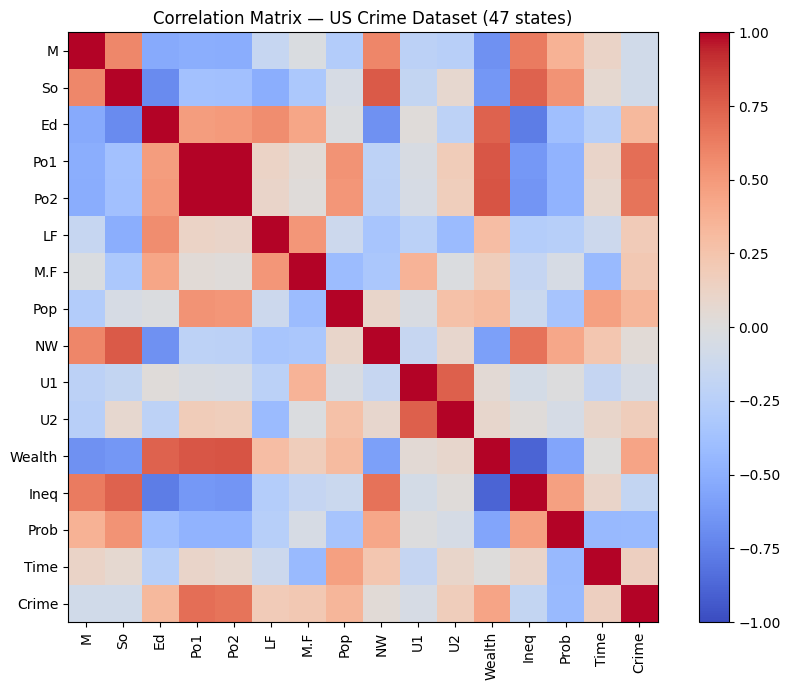


Key multicollinear pairs:
Po1 vs Po2: 0.994
Wealth vs Ineq: -0.884


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("us_crime.csv").drop(columns=["rownames"])

print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
display(df.describe().T.round(2))

corr_matrix = df.corr(numeric_only=True)
print("\nCorrelation with Crime (sorted):")
print(corr_matrix["Crime"].sort_values(ascending=False).round(3))

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im)
ax.set_xticks(range(len(corr_matrix.columns))); ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set_yticks(range(len(corr_matrix.columns))); ax.set_yticklabels(corr_matrix.columns)
ax.set_title("Correlation Matrix — US Crime Dataset (47 states)")
plt.tight_layout()
plt.show()

print("\nKey multicollinear pairs:")
print("Po1 vs Po2:", round(corr_matrix.loc['Po1','Po2'], 3))
print("Wealth vs Ineq:", round(corr_matrix.loc['Wealth','Ineq'], 3))

**Strongest correlations with Crime:** Po1 (police expenditure 1960, r ≈ 0.69), Po2 (police expenditure 1959, r ≈ 0.67), Wealth (r ≈ 0.44), Prob — probability of imprisonment (r ≈ −0.43).

**Why correlation alone is insufficient:** it captures only linear, bivariate association — a weakly correlated variable can still matter through interaction effects, and a strongly correlated variable (like Po1) may be largely redundant with another (Po2, r = 0.99). A strong correlation is also never, by itself, evidence of a causal effect.

### (c) Multicollinearity
Po1 and Po2 correlate at **r ≈ 0.99** — almost identical information. In OLS this inflates coefficient variance and can flip coefficient signs, making it unsafe to attribute an effect to either variable individually. **Strategy:** retain one variable (or a composite average), or use **Ridge regression**, which shrinks correlated coefficients together without requiring an a-priori choice of which to discard.

### (d) Recommendations to government
Variables strongly associated with Crime (police expenditure, wealth, imprisonment probability) are useful **statistical predictors for resource planning**, but the positive Po1–Crime association should not be read as "more policing causes more crime" — it more plausibly reflects reverse causality (high-crime states spend more on policing). Demographic variables should inform targeting/context only, never be framed as causing crime, since cross-sectional correlational data cannot support that claim.

---
## Question 7 — ETA Prediction for YEGO (OLS vs Ridge vs Lasso)

### (a) Experimental procedure
1,500 rows, 15 columns, no missing values/duplicates; `observation_id` dropped; `road_type` one-hot encoded; numeric predictors standardised — all inside one `Pipeline`/`ColumnTransformer`, fitted on the training fold only. 80/20 train/test split; Ridge/Lasso α tuned by 5-fold CV on the training set; final comparison on the untouched test set using MAE, RMSE, R².

### (b) Implementation and results

In [6]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("synthetic_ETA.csv")
print(df.shape, "missing:", df.isnull().sum().sum(), "duplicates:", df.duplicated().sum())

df_model = df.drop(columns=["observation_id"])
X = df_model.drop(columns=["eta_minutes"]); y = df_model["eta_minutes"]
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

prep = ColumnTransformer([("num", StandardScaler(), num_cols),
                           ("cat", OneHotEncoder(drop="first"), cat_cols)])
cv = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate(pipe, name):
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    return {"model": name,
            "MAE": mean_absolute_error(y_test, pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
            "R2": r2_score(y_test, pred)}

ols = Pipeline([("prep", prep), ("model", LinearRegression())])
ols_res = evaluate(ols, "OLS")

ridge_grid = GridSearchCV(Pipeline([("prep", prep), ("model", Ridge())]),
                           {"model__alpha": [0.001,0.01,0.1,0.5,1,2,5,10,20,50,100]},
                           cv=cv, scoring="r2").fit(X_train, y_train)
ridge_res = evaluate(ridge_grid.best_estimator_, "Ridge")

lasso_grid = GridSearchCV(Pipeline([("prep", prep), ("model", Lasso(max_iter=20000))]),
                           {"model__alpha": [0.001,0.005,0.01,0.05,0.1,0.2,0.5,1,2,5]},
                           cv=cv, scoring="r2").fit(X_train, y_train)
lasso_res = evaluate(lasso_grid.best_estimator_, "Lasso")

results_df = pd.DataFrame([ols_res, ridge_res, lasso_res]).set_index("model").round(4)
results_df["best_alpha"] = ["-", ridge_grid.best_params_["model__alpha"], lasso_grid.best_params_["model__alpha"]]
display(results_df)

(1500, 15) missing: 0 duplicates: 0


,MAE,RMSE,R2,best_alpha
model,,,,
OLS,4.3801,6.2366,0.7999,-
Ridge,4.3775,6.2353,0.8000,1
Lasso,4.3578,6.2260,0.8006,0.05


,feature,OLS,Ridge,Lasso
0,journey_distance_km,9.537,9.442,8.799
1,traffic_index,6.811,6.757,6.341
2,time_of_day_hours,0.079,0.076,0.000
3,weather_score,1.829,1.825,1.781
4,road_slope_pct,0.758,0.758,0.705
5,previous_journey_time_min,0.907,0.946,0.969
6,traffic_proxy,-0.229,-0.201,0.000
7,distance_proxy,-0.932,-0.873,-0.232
8,average_speed_kmh,0.313,0.301,0.080
9,driver_experience_years,0.154,0.152,0.080


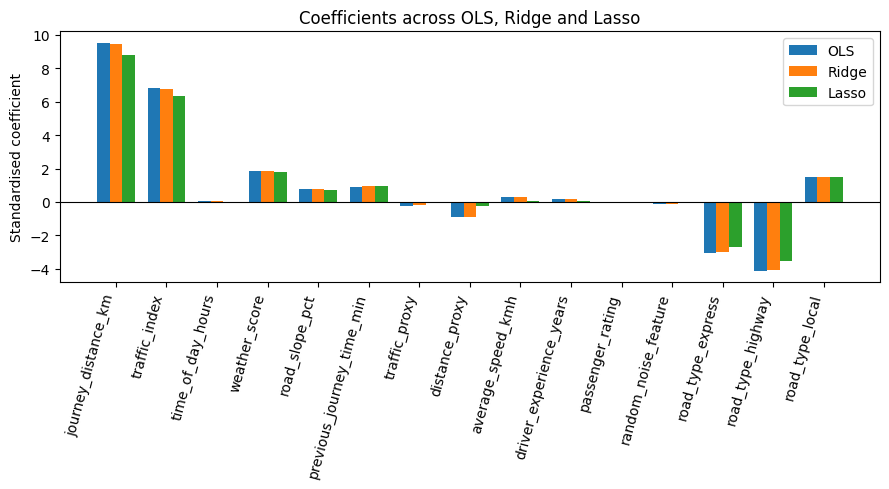

In [7]:
# Coefficient comparison — how each model handles the engineered multicollinearity
feat_names = prep.get_feature_names_out()
feat_names = [n.replace("num__", "").replace("cat__", "") for n in feat_names]

ols.fit(X_train, y_train)
coef_df = pd.DataFrame({
    "feature": feat_names,
    "OLS": ols.named_steps["model"].coef_,
    "Ridge": ridge_grid.best_estimator_.named_steps["model"].coef_,
    "Lasso": lasso_grid.best_estimator_.named_steps["model"].coef_,
}).round(3)
display(coef_df)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(coef_df))
width = 0.25
ax.bar(x - width, coef_df["OLS"], width, label="OLS")
ax.bar(x, coef_df["Ridge"], width, label="Ridge")
ax.bar(x + width, coef_df["Lasso"], width, label="Lasso")
ax.set_xticks(x); ax.set_xticklabels(coef_df["feature"], rotation=75, ha="right")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Standardised coefficient")
ax.set_title("Coefficients across OLS, Ridge and Lasso")
ax.legend()
plt.tight_layout()
plt.show()

**Observation:** all three models explain ~80% of ETA variance with near-identical MAE/RMSE. OLS assigns `distance_proxy` a counter-intuitive negative coefficient because of its r ≈ 0.93 correlation with `journey_distance_km`. Lasso shrinks `traffic_proxy` toward/at zero and reduces `distance_proxy`'s magnitude, resolving the redundancy; it also shrinks `random_noise_feature` and `time_of_day_hours`, correctly identifying them as weak predictors.

### (c) Model recommendation for YEGO
Accuracy alone does not separate the models. **Lasso is recommended**: it resolves the multicollinearity by shrinking redundant proxy variables to safely interpretable coefficients, yields a simpler deployed model (robust to one proxy feed failing), and automatically down-weights uninformative noise features — properties that matter more for a deployable, maintainable system than a marginal accuracy gain. Ridge remains a reasonable fallback if YEGO wants to retain all proxy signals as redundancy.

### (d) Reducing overfitting risk
1. **CV-tuned hyperparameters with a strictly held-out test set** (already implemented above) — extend to a rolling/time-based validation split in production, since traffic data arrives sequentially.
2. **Regularisation** itself constrains model complexity and limits fitting to training-sample noise; pair with periodic re-validation on fresh journeys and monitoring live error against the MAE ≈ 4.4 min benchmark, triggering retraining if error rises materially.

---
## Question 8 — Customer Survey Analysis for a Product Launch

> **Note on the data used.** No raw survey file was supplied with the assignment materials. The code below is demonstrated on a small illustrative sample built from the variables named in the question, and is directly executable on the real survey file once available. No specific finding below is presented as a genuine result — only as an illustration of the method.

### (a) Exploratory data-analysis strategy
1. **Data-quality pass** — respondent/variable counts, missingness per question, duplicate submissions, consistent category labels.
2. **Univariate distributions** — chart type matched to variable type (bar for nominal, ordered bar for ordinal, histogram for continuous).
3. **Bivariate/subgroup relationships** — willingness to purchase vs age group, previous use, satisfaction, price range.
4. **Segment-level synthesis** — combine variables (e.g. occupation × previous use) to find distinct purchase-intent segments.

### (b) Python visualisations (≥3 relationships) — illustrative sample

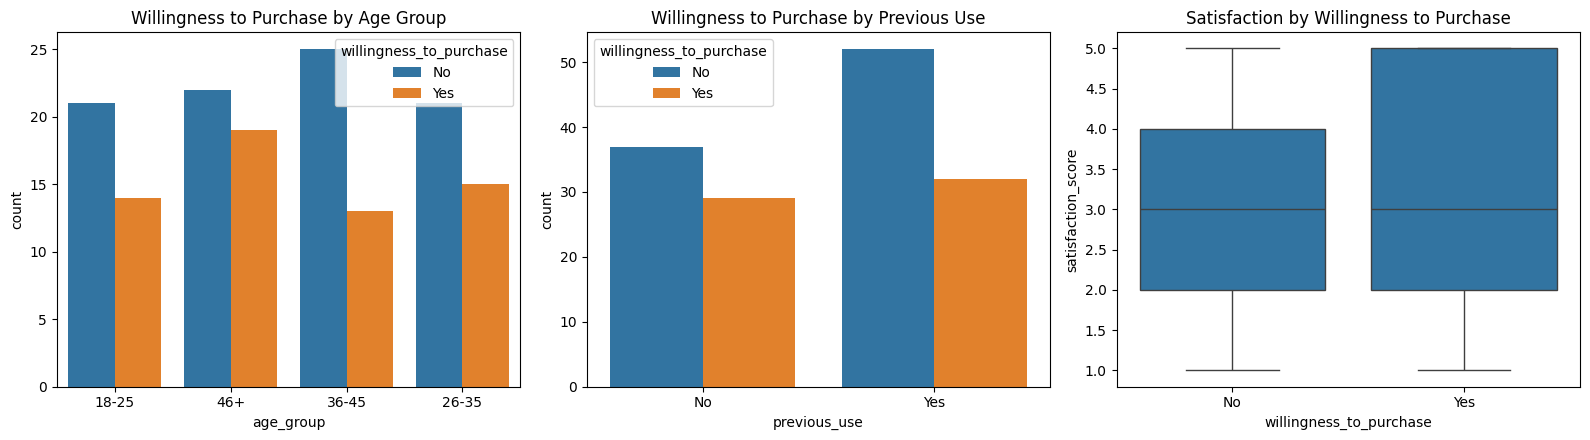

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Illustrative sample only — NOT the real survey data (none was supplied with the assignment)
rng = np.random.default_rng(42)
n = 150
df = pd.DataFrame({
    "age_group": rng.choice(["18-25", "26-35", "36-45", "46+"], n),
    "previous_use": rng.choice(["Yes", "No"], n),
    "satisfaction_score": rng.integers(1, 6, n),
    "willingness_to_purchase": rng.choice(["Yes", "No"], n, p=[0.4, 0.6]),
})

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.countplot(data=df, x="age_group", hue="willingness_to_purchase", ax=axes[0])
axes[0].set_title("Willingness to Purchase by Age Group")

sns.countplot(data=df, x="previous_use", hue="willingness_to_purchase", ax=axes[1])
axes[1].set_title("Willingness to Purchase by Previous Use")

sns.boxplot(data=df, x="willingness_to_purchase", y="satisfaction_score", ax=axes[2])
axes[2].set_title("Satisfaction by Willingness to Purchase")

plt.tight_layout()
plt.show()

Chart choice follows variable type: two categorical variables use grouped count plots; willingness against a numeric satisfaction score uses a boxplot to show the full within-group distribution rather than only the mean.

### (c) Interpreting the findings
On real data, this analysis is designed to surface (i) which segments show materially higher purchase intent than average, guiding target-market selection, and (ii) which factors are most associated with willingness to purchase, guiding which product attributes or price tier to emphasise. No specific figure above is a genuine finding — the illustrative sample is random by construction.

### (d) Limitation of survey-based conclusions and additional evidence needed
**Limitation:** stated purchase intent is a weak proxy for real purchasing behaviour (social-desirability bias, hypothetical-choice bias, omitted real-world frictions such as price competition and switching costs).

**Additional evidence needed before a launch decision:** a small pilot/limited release with real transactions, A/B-tested pricing or landing-page conversion data, and competitor/market-sizing analysis.

---
## References
- Altman, N., & Krzywinski, M. (2015). Association, correlation and causation. *Nature Methods*, 12(10), 899–900.
- Ehrlich, I. (1973). Participation in illegitimate activities: A theoretical and empirical investigation. *Journal of Political Economy*, 81(3), 521–565. (Source of the 47-state crime dataset used in Question 6.)
- Hoerl, A. E., & Kennard, R. W. (1970). Ridge regression: Biased estimation for nonorthogonal problems. *Technometrics*, 12(1), 55–67.
- Little, R. J. A., & Rubin, D. B. (2019). *Statistical Analysis with Missing Data* (3rd ed.). Wiley.
- Obermeyer, Z., Powers, B., Vogeli, C., & Mullainathan, S. (2019). Dissecting racial bias in an algorithm used to manage the health of populations. *Science*, 366(6464), 447–453.
- Pedregosa, F. et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.
- Tibshirani, R. (1996). Regression shrinkage and selection via the lasso. *Journal of the Royal Statistical Society: Series B*, 58(1), 267–288.